### **WM811k Dataset**
{none, Center, Donut, Edge Local, Edge Ring, Local, near full, random, Scratch}

{정상, 중앙형, 도넛형, 가장자리 국부형, 가장자리 링형, 국부형, 거의 전면형, 무작위형, 스크래치형}

* Center: training 90, testing 10
* Donut: training 92, testing 10
* Edge Local: training 93, testing 10
* Edge Ring: training 92, testing 10
* Local: training 90, testing 10
* near full: training 85, testing 10
* none: training 90, testing 10
* random: training 90, testing 10
* Scratch: training 90, testing 10

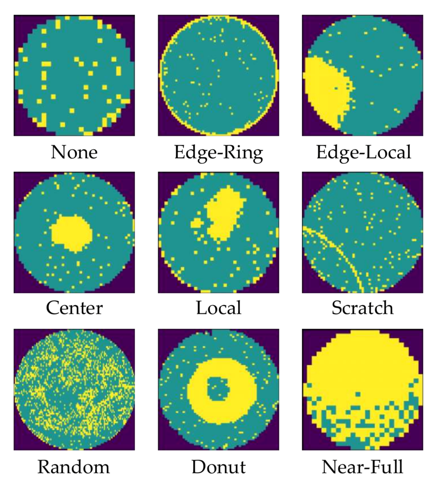

In [ ]:
# 데이터 불러오기
import numpy as np
import tensorflow as tf
import os, glob
from PIL import Image

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/gdrive')


# 경로 설정
base_dir = "/content/gdrive/My Drive/Colab Notebooks/ai_semicon/CNN/waferimages/"

train_dir = base_dir + "training"
test_dir  = base_dir + "testing"

class_names = [
    'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
    'Loc', 'Near-full', 'Random', 'Scratch', 'none'
]


# 데이터 로딩 함수
def load_WM811k_origin_dataset(base_dir, class_names, target_size=(32, 32)):
    print("Load:", base_dir)
    x_data = []
    y_data = []

    for label, class_name in enumerate(class_names):
        print("- class:", class_name)
        class_dir = os.path.join(base_dir, class_name)
        image_paths = sorted(glob.glob(os.path.join(class_dir, '*')))

        for img_path in image_paths:
            img = Image.open(img_path).convert('RGB')
            img = img.resize(target_size)
            img = np.array(img, dtype=np.float32) / 255.0

            x_data.append(img)
            y_data.append(label)

    return np.array(x_data), np.array(y_data)


# 데이터 읽기
x_train, y_train = load_WM811k_origin_dataset(train_dir, class_names)
x_test, y_test = load_WM811k_origin_dataset(test_dir, class_names)

print("before:", y_train[0:3])

y_train = to_categorical(y_train, num_classes=len(class_names))
y_test = to_categorical(y_test, num_classes=len(class_names))

print("after:", y_train[0:3])

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# CNN 모델 정의
def create_model(learning_rate=0.001):
    model = Sequential([
        Input(shape=(32, 32, 3)),

        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        Dropout(0.40),
        Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = create_model()
model.summary()


# Train / Validation Split
y_train_label = np.argmax(y_train, axis=1)

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train_label
)

print("x_tr:", x_tr.shape)
print("x_val:", x_val.shape)


# Class Weight 계산
y_tr_label = np.argmax(y_tr, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr_label),
    y=y_tr_label
)

class_weight_dict = dict(enumerate(class_weights))
print("class_weight:", class_weight_dict)


# 모델 학습
batch_size = 32
n_epoch = 100
learning_rate = 0.001

model = create_model(learning_rate=learning_rate)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
]

history = model.fit(
    x_tr,
    y_tr,
    validation_data=(x_val, y_val),
    batch_size=batch_size,
    epochs=n_epoch,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=2
)


# 최종 테스트 평가
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


# Confusion Matrix
y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_label, y_pred_label)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.show()


# Classification Report
print(classification_report(
    y_test_label,
    y_pred_label,
    target_names=class_names
))


# 결과 확인
print("train folders:", sorted(os.listdir(train_dir)))
print("test folders:", sorted(os.listdir(test_dir)))
print("class_names:", class_names)

print("Best val acc:", max(history.history["val_accuracy"]))
print("Final train acc:", history.history["accuracy"][-1])
print("Final val acc:", history.history["val_accuracy"][-1])

print("train:", np.bincount(np.argmax(y_train, axis=1)))
print("test :", np.bincount(np.argmax(y_test, axis=1)))